In [ ]:
# Conditioning on the particle type, masking the velocity field

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torchdyn.core import NeuralODE
from torchcfm.conditional_flow_matching import ExactOptimalTransportConditionalFlowMatcher
from matplotlib import animation
import numpy as np
import load_and_preprocess as lap
import train_and_eval_functions as taef
import os
import matplotlib.pyplot as plt
import math
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import h5py
from scipy.stats import norm, stats
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
def load_subdicts_from_h5(save_dir, tags_to_use=None):
    """
    Loads sub-dictionaries of NumPy arrays from HDF5 files in a directory and reconstructs the original structure.
    
    Args:
        save_dir (str): The directory where the HDF5 files are stored.
    
    Returns:
        main_dict (dict): A dictionary of dictionaries where the innermost values are NumPy arrays.
    """
    main_dict = {}
    
    for filename in os.listdir(save_dir):
        if filename.endswith(".h5") and not filename.startswith('.'):

            
            sub_dict_name = os.path.splitext(filename)[0]
            if tags_to_use is not None and sub_dict_name not in tags_to_use:
                continue
            file_path = os.path.join(save_dir, filename)
            with h5py.File(file_path, 'r') as f:
                sub_dict = {key: np.array(f[key]) for key in f}
            main_dict[sub_dict_name] = sub_dict
            print(f"Loaded {sub_dict_name} from {file_path}")
    
    return main_dict

In [4]:
plots_path = '/global/homes/m/mcohen54/ctfm_development/trained_models/trial_5/plots'
datasets = load_subdicts_from_h5(save_dir='/pscratch/sd/m/mcohen54/data/processed_data/EB_v1')


# convert x0_latent and torch_mask to torch tensors
for tag, data_dict in datasets.items():
    for key, value in data_dict.items():
        if key == 'x0_latent' or key == 'torch_mask':
            datasets[tag][key] = torch.tensor(data_dict[key]).to(device)

            
# Printing
for tag, data_dict in datasets.items():
    print(tag)
    for key, value in data_dict.items():
        print(f' {key}: {value.shape}')

Loaded mc23e_HAHMggf from /pscratch/sd/m/mcohen54/data/processed_data/EB_v1/mc23e_HAHMggf.h5
Loaded mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter from /pscratch/sd/m/mcohen54/data/processed_data/EB_v1/mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter.h5
Loaded mc23e_HNLeemu from /pscratch/sd/m/mcohen54/data/processed_data/EB_v1/mc23e_HNLeemu.h5
Loaded mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered from /pscratch/sd/m/mcohen54/data/processed_data/EB_v1/mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered.h5
Loaded EB_val from /pscratch/sd/m/mcohen54/data/processed_data/EB_v1/EB_val.h5
Loaded EB_train from /pscratch/sd/m/mcohen54/data/processed_data/EB_v1/EB_train.h5
Loaded mc23e_new_hh_bbbb_vbf_novhh_5fs_l1cvv1cv1 from /pscratch/sd/m/mcohen54/data/processed_data/EB_v1/mc23e_new_hh_bbbb_vbf_novhh_5fs_l1cvv1cv1.h5
Loaded mc23e_new_ggF_H125_a16a16_4b_ctau10_filtered from /pscratch/sd/m/mcohen54/data/processed_data/EB_v1/mc23e_new_ggF_H125_a16a16_4b_ctau10_filtered.h5
Loaded EB_test from /psc

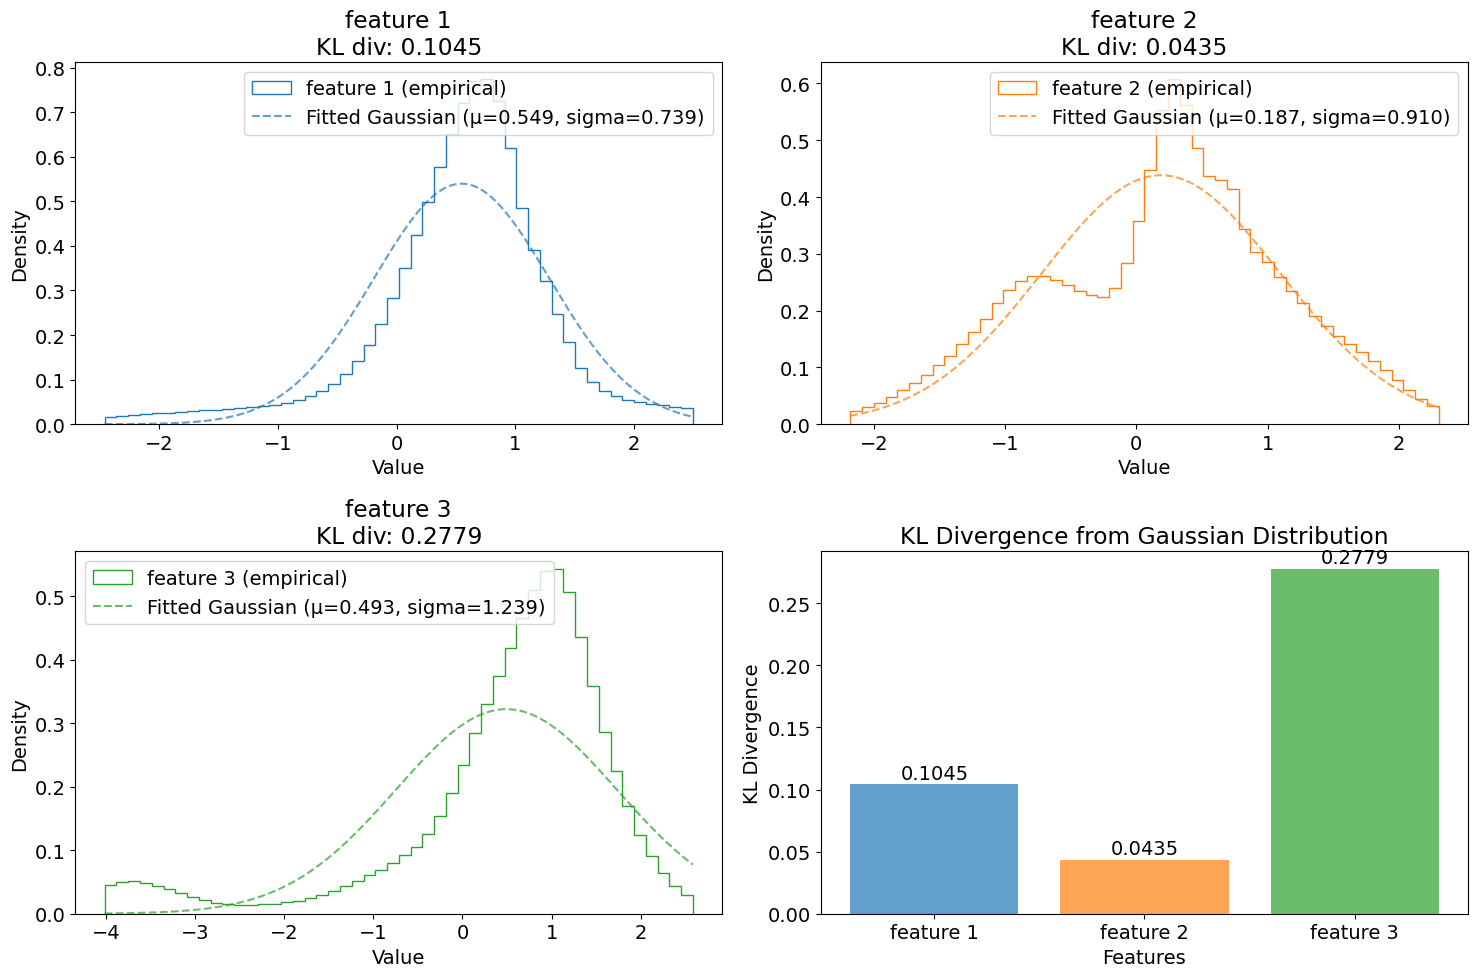

=== Gaussian Deviation Analysis ===
KL Divergence (lower = more Gaussian-like):
  feature 1: KL = 0.104498
    Fitted params: μ = 0.5492, sigma = 0.7394
  feature 2: KL = 0.043529
    Fitted params: μ = 0.1872, sigma = 0.9099
  feature 3: KL = 0.277875
    Fitted params: μ = 0.4926, sigma = 1.2389

Most Gaussian-like feature: feature 2
Least Gaussian-like feature: feature 3


In [10]:
# plot features post flow
def get_valid_feature(data_dict, feature_idx):
    # [B, N, D] for x0_latent, [B, N, 1] for mask
    x0 = data_dict['x0_latent'][:,:,feature_idx].flatten()
    mask = data_dict['torch_mask'].flatten() > 0.5
    # Ensure both are on CPU and numpy
    x0 = x0[mask].cpu().numpy()
    return x0

def calculate_kl_divergence_to_gaussian(data, bins=100):
    """
    Calculate KL divergence between empirical distribution and fitted Gaussian
    """
    # Fit Gaussian to the data
    mu, sigma = norm.fit(data)
    
    # Create histogram
    hist, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Calculate empirical probabilities (normalize histogram)
    empirical_probs = hist * bin_width
    
    # Calculate theoretical Gaussian probabilities
    gaussian_probs = norm.pdf(bin_centers, mu, sigma) * bin_width
    
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    empirical_probs = np.maximum(empirical_probs, epsilon)
    gaussian_probs = np.maximum(gaussian_probs, epsilon)
    
    # Calculate KL divergence: D_KL(P||Q) = sum(P * log(P/Q))
    # where P is empirical and Q is Gaussian
    kl_div = np.sum(empirical_probs * np.log(empirical_probs / gaussian_probs))
    
    return kl_div, mu, sigma


plt.figure(figsize=(15, 10))
feature_names = ['feature 1', 'feature 2', 'feature 3']
colors = ['C0', 'C1', 'C2']

# Store results
kl_divergences = []
gaussian_params = []

for i in range(3):
    # filter by percentiles
    data = get_valid_feature(datasets['EB_test'], i)
    lower, upper = np.percentile(data, [1, 99])
    data = data[(data >= lower) & (data <= upper)]
    
    # Calculate KL divergence and fitted parameters
    kl_div, mu, sigma = calculate_kl_divergence_to_gaussian(data)
    kl_divergences.append(kl_div)
    gaussian_params.append((mu, sigma))

    # Plot histogram
    plt.subplot(2, 2, i+1)
    plt.hist(data, bins=50, histtype='step', density=True, label=f'{feature_names[i]} (empirical)', color=colors[i])
    
    # Overlay fitted Gaussian
    x = np.linspace(data.min(), data.max(), 200)
    plt.plot(x, norm.pdf(x, mu, sigma), color=colors[i], linestyle='dashed', alpha=0.7, 
             label=f'Fitted Gaussian (μ={mu:.3f}, sigma={sigma:.3f})')
    
    plt.legend()
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title(f'{feature_names[i]}\nKL div: {kl_div:.4f}')

# Summary plot
plt.subplot(2, 2, 4)
x_pos = np.arange(len(feature_names))
plt.bar(x_pos, kl_divergences, color=colors, alpha=0.7)
plt.xlabel('Features')
plt.ylabel('KL Divergence')
plt.title('KL Divergence from Gaussian Distribution')
plt.xticks(x_pos, feature_names)

# Add text annotations
for i, kl_div in enumerate(kl_divergences):
    plt.text(i, kl_div + 0.001, f'{kl_div:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{plots_path}/gaussian_deviation_analysis.png', bbox_inches='tight')
plt.show()

# Print summary results
print("=== Gaussian Deviation Analysis ===")
print("KL Divergence (lower = more Gaussian-like):")
for i, (name, kl_div) in enumerate(zip(feature_names, kl_divergences)):
    mu, sigma = gaussian_params[i]
    print(f"  {name}: KL = {kl_div:.6f}")
    print(f"    Fitted params: μ = {mu:.4f}, sigma = {sigma:.4f}")

print(f"\nMost Gaussian-like feature: {feature_names[np.argmin(kl_divergences)]}")
print(f"Least Gaussian-like feature: {feature_names[np.argmax(kl_divergences)]}")

In [11]:
def neg_log_prob_gaussian(x0, mask):
    """
    Compute -log p(x0) under a standard N-dimensional Gaussian,
    masking out invalid (padded) particles.

    Args:
        x0: [B, N, D] tensor
        mask: [B, N, 1] binary mask tensor (1 = valid, 0 = padded)

    Returns:
        nll: [B] tensor, negative log-likelihood per jet
    """
    # Standard Gaussian: log p(x) = -0.5 * (x^2 + log(2π))
    log_probs = -0.5 * (x0 ** 2 + torch.log(torch.tensor(2 * torch.pi, device=x0.device)))

    # Apply mask and sum over particles and features
    binary_mask = (mask > 0).float()
    log_probs_masked = log_probs * binary_mask  # [N, 15, 3]
    log_likelihood = log_probs_masked.sum(dim=(1, 2))  # [N]

    # Return negative log-likelihood
    return -log_likelihood  # [N]

In [13]:
skip_tags = ['EB_train', 'EB_val']
for tag, data_dict in datasets.items():
    if tag in skip_tags:
        continue
    data_dict['AD_scores'] = neg_log_prob_gaussian(data_dict['x0_latent'], data_dict['torch_mask']).cpu().numpy()  # [B]
    print(tag)
    print("Mean AD score per event:", np.mean(data_dict['AD_scores']))

mc23e_HAHMggf
Mean AD score per event: 76.429634
mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter
Mean AD score per event: 33.944897
mc23e_HNLeemu
Mean AD score per event: 34.743954
mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered
Mean AD score per event: 49.053364
mc23e_new_hh_bbbb_vbf_novhh_5fs_l1cvv1cv1
Mean AD score per event: 66.24453
mc23e_new_ggF_H125_a16a16_4b_ctau10_filtered
Mean AD score per event: 59.21143
EB_test
Mean AD score per event: 32.67864
mc23e_new_Znunu_FxFx3jHT2bias_SW_pTvv70_BFilter
Mean AD score per event: 46.606907


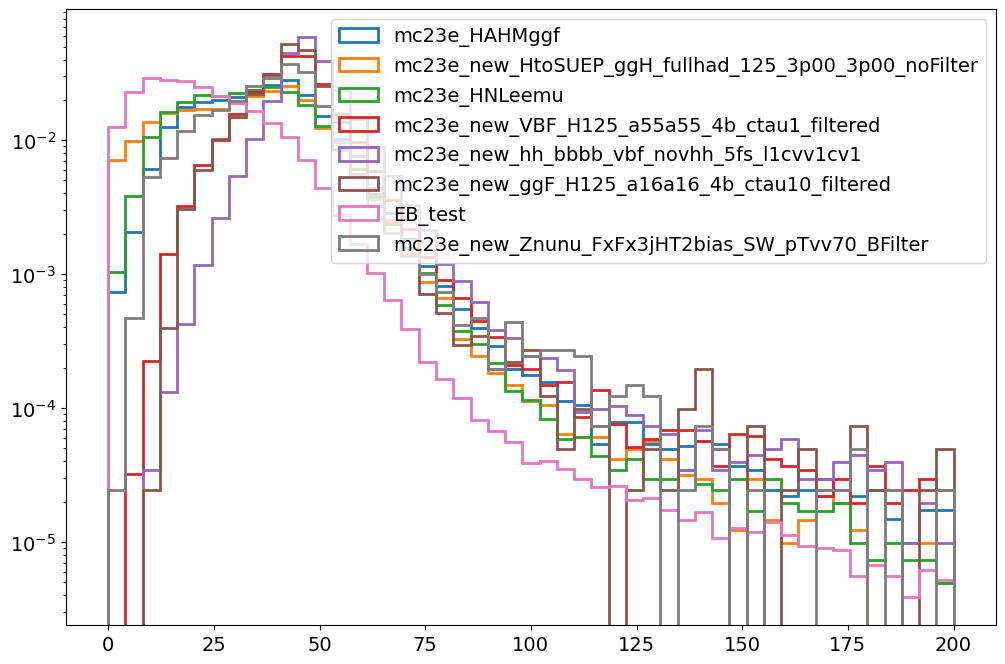

In [16]:
# Plot AD scores
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 200, 50)
for tag, data_dict in datasets.items():
    if tag in skip_tags:
        continue
    plt.hist(data_dict['AD_scores'], bins=bins, histtype='step', density=True, label=tag, linewidth=2)

plt.yscale('log')
plt.legend()
plt.savefig(f'{plots_path}/AD_scores_histograms.png')
plt.show()
plt.close()

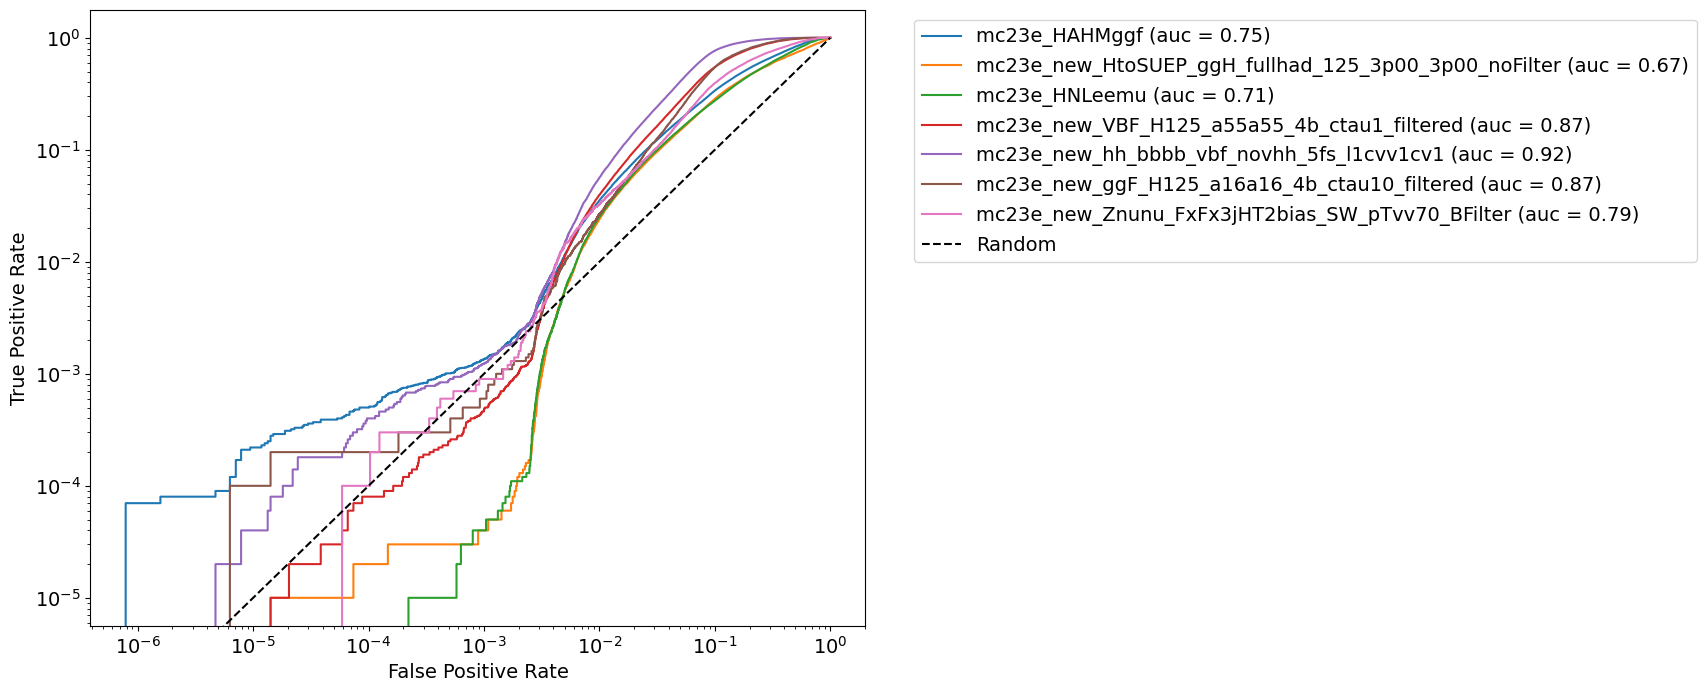

In [17]:
# ROC curve
plt.figure(figsize=(10, 8))
    
bkg_scores = datasets['EB_test']['AD_scores']

for tag, data_dict in datasets.items():
    if 'EB' in tag:
        continue

    sig_scores = data_dict['AD_scores']
    combined_scores = np.concatenate([bkg_scores, sig_scores], axis=0)
    combined_labels = np.concatenate([np.zeros_like(bkg_scores), np.ones_like(sig_scores)], axis=0)

    fpr, tpr, thresholds = roc_curve(combined_labels, combined_scores)
    auroc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{tag} (auc = {auroc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.yscale('log')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(f'{plots_path}/roc_curves.png')
plt.show()
plt.close()